## Define KPIs 
#### (geometric compounding)

In [5]:
import pandas as pd
import numpy as np

# --- Module 1: Configuration ---
CONFIG = {
    'risk_free_rate': 0.0
}

# --- Module 2: Performance Metrics Calculation ---
def calculate_performance_metrics(returns_series: pd.Series, freq: str = '1H') -> dict:
    """
    Calculates a dictionary of performance metrics based on a series of returns,
    using true geometric compounding for cumulative & annualized returns.

    Args:
        returns_series (pd.Series): periodic (e.g. hourly/daily) simple returns R_t.
        freq (str): data frequency for annualization ('1H','4H','1D', etc).

    Returns:
        dict: KPI metrics including Cumulative Return, CAGR, volatility, ratios, etc.
    """
    # handle empty series
    if returns_series.empty:
        return {
            'Cumulative Return':      0.0,
            'Annualized Return':      0.0,
            'Annualized Volatility':  0.0,
            'Sharpe Ratio':           0.0,
            'Sortino Ratio':          0.0,
            'Maximum Drawdown':       0.0,
            'Calmar Ratio':           0.0,
            'Kelly Criterion':        0.0
        }

    # --- determine periods per year ---
    f = freq.upper()
    if 'H' in f:
        periods_per_year = 24 * 365 / int(f.replace('H',''))
    elif 'D' in f:
        periods_per_year = 252
    else:
        periods_per_year = 24 * 365

    # number of observations
    n_periods = returns_series.shape[0]

    # --- Cumulative Return (geometric) ---
    cumulative_return = (1 + returns_series).prod() - 1

    # --- Annualized Return (CAGR) ---
    # (1 + total_return)^(periods_per_year / n_periods) - 1
    total_return = 1 + cumulative_return
    annualized_return = total_return ** (periods_per_year / n_periods) - 1

    # --- Annualized Volatility ---
    annualized_volatility = returns_series.std(ddof=1) * np.sqrt(periods_per_year)

    # --- Sharpe Ratio (using CAGR) ---
    excess_return = annualized_return - CONFIG['risk_free_rate']
    sharpe_ratio = excess_return / annualized_volatility if annualized_volatility != 0 else 0.0

    # --- Sortino Ratio ---
    downside = returns_series[returns_series < 0]
    downside_dev = (
        downside.std(ddof=1) * np.sqrt(periods_per_year)
        if not downside.empty else 0.0
    )
    sortino_ratio = excess_return / downside_dev if downside_dev != 0 else 0.0

    # --- Equity curve & Max Drawdown ---
    equity_curve = (1 + returns_series).cumprod()
    running_max   = equity_curve.cummax()
    drawdown      = (equity_curve - running_max) / running_max
    max_drawdown  = drawdown.min()

    # --- Calmar Ratio ---
    calmar_ratio = (
        annualized_return / abs(max_drawdown)
        if max_drawdown != 0 else 0.0
    )

    # --- Kelly Criterion ---
    traded = returns_series[returns_series != 0]
    if not traded.empty:
        wins   = traded[traded > 0]
        losses = traded[traded < 0]
        W = len(wins) / len(traded)
        avg_win  = wins.mean() if len(wins)  else 0.0
        avg_loss = losses.mean() if len(losses) else 0.0
        R = avg_win / abs(avg_loss) if avg_loss != 0 else np.inf
        kelly = W - (1 - W) / R if (R > 0 and R != np.inf) else 0.0
    else:
        kelly = 0.0

    return {
        'Cumulative Return':      cumulative_return,
        'Annualized Return':      annualized_return,
        'Annualized Volatility':  annualized_volatility,
        'Sharpe Ratio':           sharpe_ratio,
        'Sortino Ratio':          sortino_ratio,
        'Maximum Drawdown':       max_drawdown,
        'Calmar Ratio':           calmar_ratio,
        'Kelly Criterion':        kelly
    }

## AMIRA
### Compare strategies (equal-weight portfolio): 
#### buy_and_hold, long_only, mean_reversion, long_short, trend_following

In [6]:
import os
import warnings

import numpy as np
import pandas as pd

# ----------------------------------------------------------------------------#
# (Assume calculate_performance_metrics is already defined in the notebook)
# ----------------------------------------------------------------------------#
warnings.filterwarnings("ignore")

# ----------------------------------------------------------------------------#
# Configuration
# ----------------------------------------------------------------------------#
DATA_ROOT        = "data/resampled-v2"
PRED_ROOT        = "results/ARIMA"    # your per-coin ARIMA signal files live here
OUTPUT_DIR       = "results/Backtest"
SPLITS           = [
    ("2024-06-01 (80/20)", "ratio"),
    ("2024-10-01",         "2024-10-01"),
    ("2025-01-01",         "2025-01-01"),
]
INTERVALS        = ["1min", "10min", "1h", "1d"]
STRATEGIES       = ["buy_and_hold", "long_only", "mean_reversion", "long_short", "trend_following"]
PERIODS_PER_YEAR = {"1min":365*24*60, "10min":365*24*6, "1h":365*24, "1d":365}

# ----------------------------------------------------------------------------#
# Strategy parameters & engine
# ----------------------------------------------------------------------------#
STRAT_CONFIG = {
    "commission_rate": 0.0,
    "slippage_factor": 0.0,
    "strategy_params": {
        "mean_reversion": {"bb_window":20, "bb_std_dev":2.0},
        "long_short":      {"buy_threshold":0.5, "sell_threshold":0.5},
        "trend_following": {"sma_window":200},
    }
}

def generate_mean_reversion_positions(data):
    w  = STRAT_CONFIG["strategy_params"]["mean_reversion"]["bb_window"]
    s  = STRAT_CONFIG["strategy_params"]["mean_reversion"]["bb_std_dev"]
    m  = data["close"].rolling(w).mean()
    sd = data["close"].rolling(w).std()
    ub = m + s * sd
    lb = m - s * sd
    sig = pd.Series(0, index=data.index)
    sig[data["close"] < lb] = 1
    sig[data["close"] > ub] = -1
    return sig.replace(0, method="ffill").fillna(0)

def generate_buy_and_hold_positions(data):
    return pd.Series(1, index=data.index)

def generate_long_only_positions(preds):
    p   = STRAT_CONFIG["strategy_params"]["long_short"]["buy_threshold"]
    sig = (preds > p).astype(int)
    return sig

def generate_long_short_positions(preds):
    p   = STRAT_CONFIG["strategy_params"]["long_short"]["buy_threshold"]
    q   = STRAT_CONFIG["strategy_params"]["long_short"]["sell_threshold"]
    sig = pd.Series(0, index=preds.index)
    sig[preds > p]       = 1
    sig[(1 - preds) > q] = -1
    return sig

def generate_trend_following_positions(data, preds):
    w     = STRAT_CONFIG["strategy_params"]["trend_following"]["sma_window"]
    trend = data["close"].rolling(w).mean()
    sig   = pd.Series(0, index=data.index)
    sig[(preds == 1) & (data["close"] > trend)]  = 1
    sig[(preds == -1) & (data["close"] < trend)] = -1
    return sig

def run_vectorized_backtest(price_data, positions):
    ret    = price_data["open"].pct_change().shift(-1)
    pos    = positions.shift(1).fillna(0)
    gross  = pos * ret
    trades = pos.diff().abs().fillna(0)
    costs  = trades * STRAT_CONFIG["commission_rate"] + trades * ret.abs() * STRAT_CONFIG["slippage_factor"]
    net    = gross - costs
    return net.fillna(0)

def generate_strategy_positions(name, data, preds=None):
    if name == "buy_and_hold":
        return generate_buy_and_hold_positions(data)
    if name == "long_only":
        if preds is None:
            raise ValueError("Predictions required for long_only")
        return generate_long_only_positions(preds)
    if name == "mean_reversion":
        return generate_mean_reversion_positions(data)
    if name == "long_short":
        if preds is None:
            raise ValueError("Predictions required for long_short")
        return generate_long_short_positions(preds)
    if name == "trend_following":
        if preds is None:
            raise ValueError("Predictions required for trend_following")
        return generate_trend_following_positions(data, preds)
    raise ValueError(f"Unknown strategy: {name}")

def calculate_portfolio_return(name, weights, all_data, all_preds=None):
    returns = {}
    for coin, w in weights.items():
        df_coin = all_data.get(coin)
        if df_coin is None:
            continue
        preds = None
        if name in ["long_short", "trend_following", "long_only"]:
            preds = all_preds.get(coin)
            if preds is None:
                continue
        sig   = generate_strategy_positions(name, df_coin, preds)
        net_r = run_vectorized_backtest(df_coin, sig)
        returns[coin] = net_r * w
    if not returns:
        return pd.Series(dtype=float)
    df_ret = pd.DataFrame(returns).fillna(0)
    return df_ret.sum(axis=1)

# ----------------------------------------------------------------------------#
# Comparison pipeline using calculate_performance_metrics
# ----------------------------------------------------------------------------#
os.makedirs(OUTPUT_DIR, exist_ok=True)
records = []

for split_label, dirname in SPLITS:
    for iv in INTERVALS:
        # load test prices
        test_fp = os.path.join(DATA_ROOT, dirname, f"test_{iv}.parquet")
        df_test = pd.read_parquet(test_fp)
        df_test["timestamp"] = pd.to_datetime(df_test["timestamp"])
        coins = df_test["coin_id"].unique()

        # build per-coin price DataFrames
        all_data = {
            c: df_test[df_test.coin_id==c]
               .set_index("timestamp")[["open","high","low","close"]]
            for c in coins
        }

        # load your ARIMA-generated signals
        all_preds = {}
        for c in coins:
            pred_fp = os.path.join(PRED_ROOT, dirname, iv, f"{c}.parquet")
            if os.path.exists(pred_fp):
                pdf = pd.read_parquet(pred_fp)
                all_preds[c] = pdf["signal"]

        # equal weights
        weights = {c: 1/len(all_data) for c in all_data} if all_data else {}

        for strat in STRATEGIES:
            port_ret = calculate_portfolio_return(strat, weights, all_data, all_preds)

            # compute all KPIs (including cumulative return) via our module
            kpis = calculate_performance_metrics(port_ret, freq=iv)

            rec = {
                "split":        split_label,
                "interval":     iv,
                "strategy":     strat,
                # unpack all metrics from kpis
                **{
                    "cum_return":            kpis["Cumulative Return"],
                    "annualized_return":     kpis["Annualized Return"],
                    "annualized_volatility": kpis["Annualized Volatility"],
                    "sharpe_ratio":          kpis["Sharpe Ratio"],
                    "sortino_ratio":         kpis["Sortino Ratio"],
                    "max_drawdown":          kpis["Maximum Drawdown"],
                    "calmar_ratio":          kpis["Calmar Ratio"],
                    "kelly_criterion":       kpis["Kelly Criterion"],
                }
            }
            records.append(rec)

df_res = pd.DataFrame(records)
print(df_res)
out_fp = os.path.join(OUTPUT_DIR, "ARIMA_strategy.csv")
df_res.to_csv(out_fp, index=False)
print("Saved comparison to", out_fp)

                 split interval         strategy  cum_return  \
0   2024-06-01 (80/20)     1min     buy_and_hold    0.323710   
1   2024-06-01 (80/20)     1min        long_only    0.324240   
2   2024-06-01 (80/20)     1min   mean_reversion    0.567938   
3   2024-06-01 (80/20)     1min       long_short    0.324240   
4   2024-06-01 (80/20)     1min  trend_following    0.642645   
5   2024-06-01 (80/20)    10min     buy_and_hold    0.315499   
6   2024-06-01 (80/20)    10min        long_only    0.359095   
7   2024-06-01 (80/20)    10min   mean_reversion    0.104183   
8   2024-06-01 (80/20)    10min       long_short    0.304333   
9   2024-06-01 (80/20)    10min  trend_following    0.093554   
10  2024-06-01 (80/20)       1h     buy_and_hold    0.311032   
11  2024-06-01 (80/20)       1h        long_only    0.357021   
12  2024-06-01 (80/20)       1h   mean_reversion    0.320089   
13  2024-06-01 (80/20)       1h       long_short    0.307607   
14  2024-06-01 (80/20)       1h  trend_f

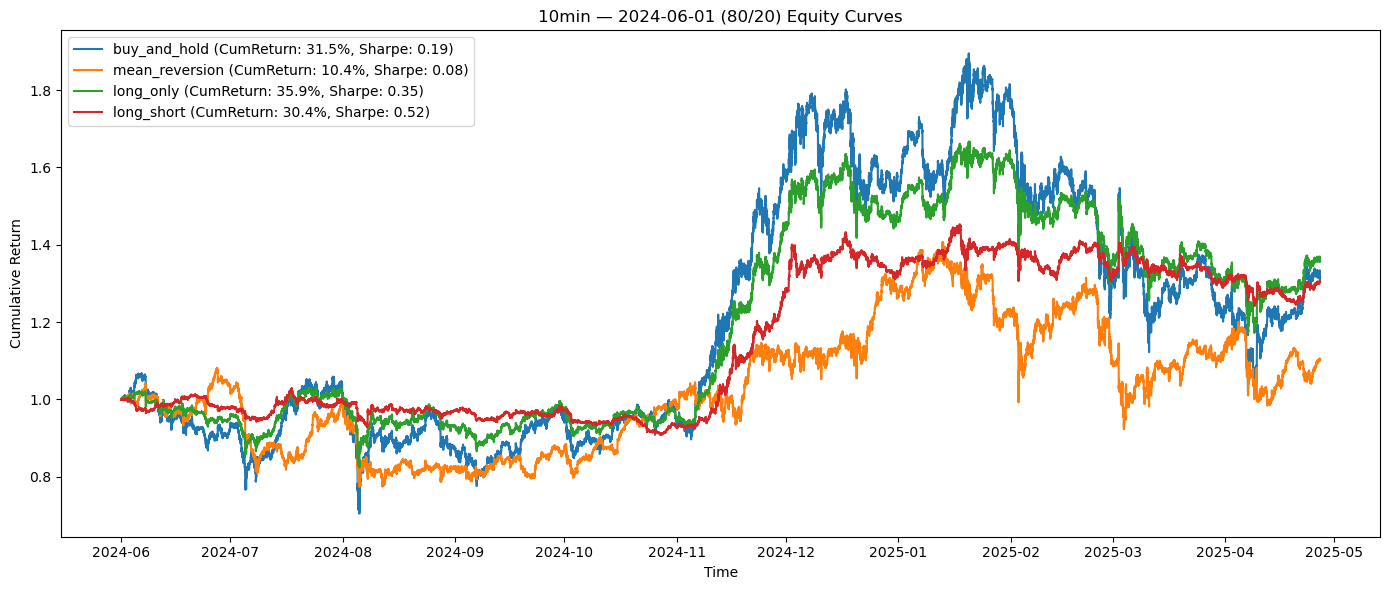

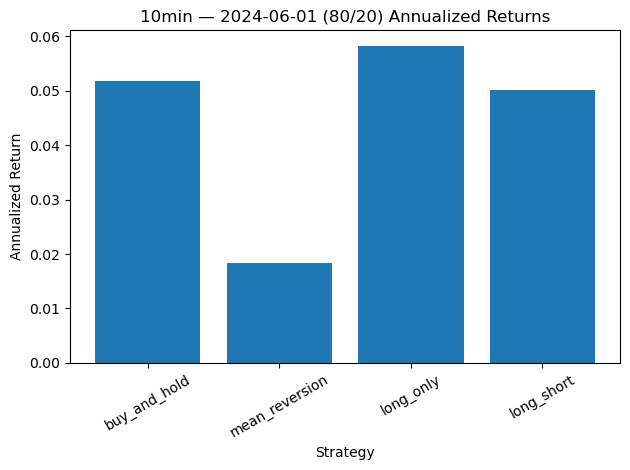


=== Metrics for 2024-06-01 (80/20), interval=10min ===
                Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold               0.3155             0.0518                 0.2703        0.1917         0.2491           -0.4664        0.1111           0.0054
mean_reversion             0.1042             0.0184                 0.2293        0.0804         0.0971           -0.3436        0.0536           0.0036
long_only                  0.3591             0.0582                 0.1664        0.3496         0.4509           -0.3005        0.1936           0.0072
long_short                 0.3043             0.0502                 0.0957        0.5244         0.7101           -0.1452        0.3455           0.0092


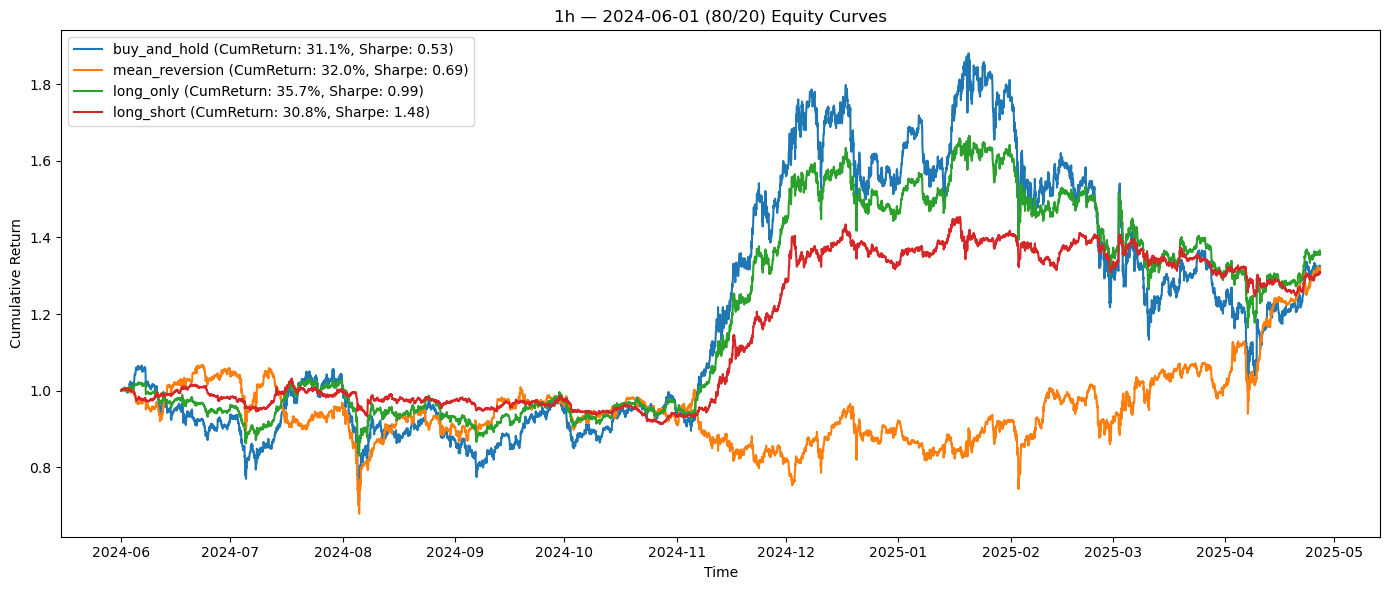

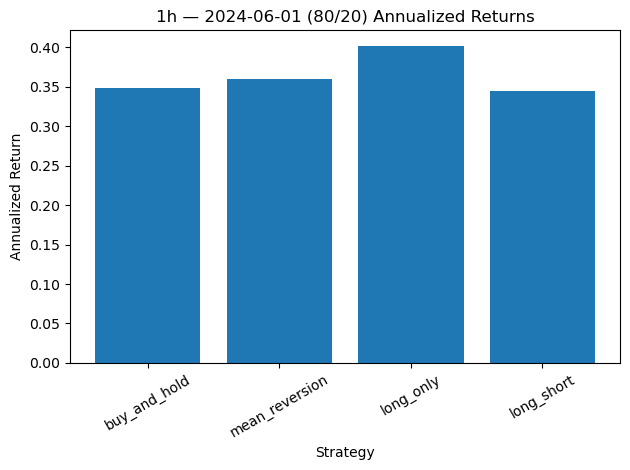


=== Metrics for 2024-06-01 (80/20), interval=1h ===
                Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold               0.3110             0.3490                 0.6569        0.5313         0.6628           -0.4640        0.7523           0.0133
mean_reversion             0.3201             0.3593                 0.5240        0.6858         0.8340           -0.3641        0.9870           0.0150
long_only                  0.3570             0.4014                 0.4051        0.9910         1.2337           -0.3006        1.3355           0.0178
long_short                 0.3076             0.3451                 0.2336        1.4776         2.0060           -0.1431        2.4113           0.0225


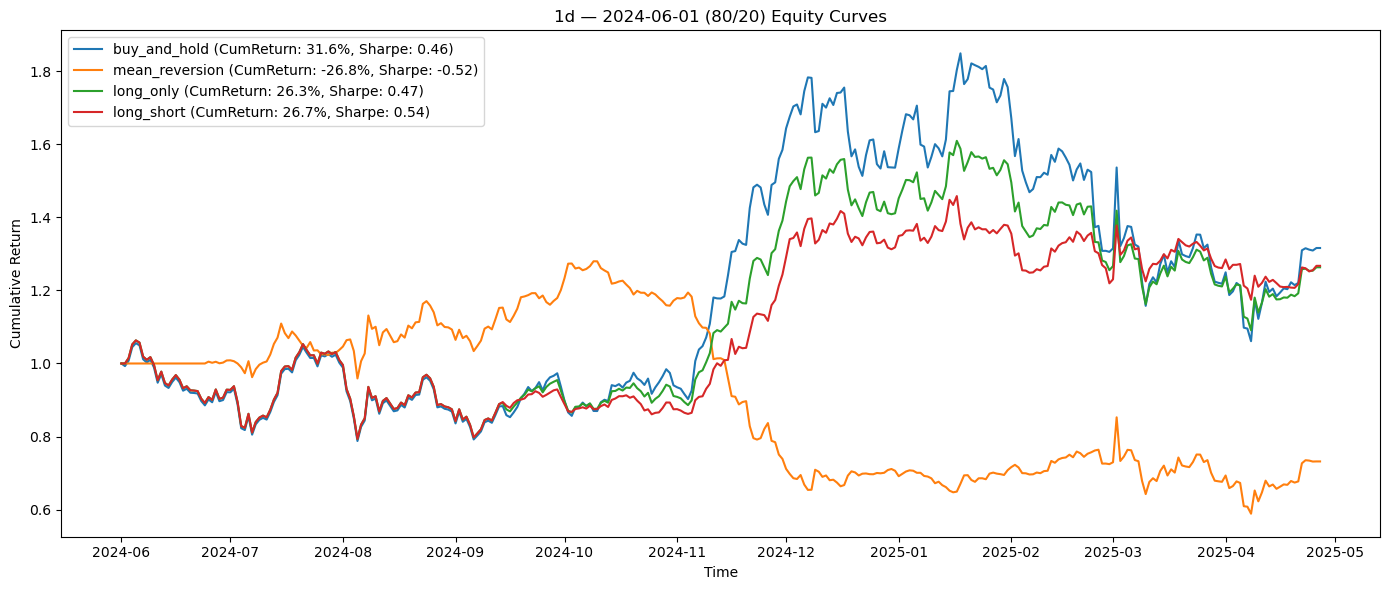

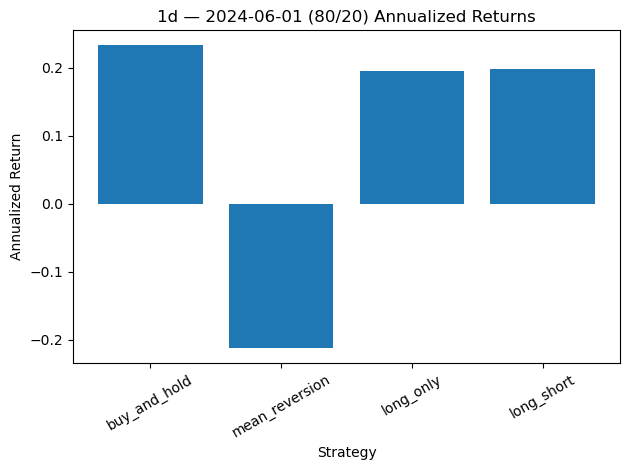


=== Metrics for 2024-06-01 (80/20), interval=1d ===
                Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold               0.3162             0.2326                 0.5053        0.4604         0.6419           -0.4262        0.5459           0.0577
mean_reversion            -0.2681            -0.2115                 0.4082       -0.5181        -0.6616           -0.5400       -0.3917          -0.0410
long_only                  0.2634             0.1948                 0.4168        0.4674         0.6561           -0.3221        0.6047           0.0566
long_short                 0.2674             0.1977                 0.3646        0.5422         0.7659           -0.2538        0.7790           0.0630


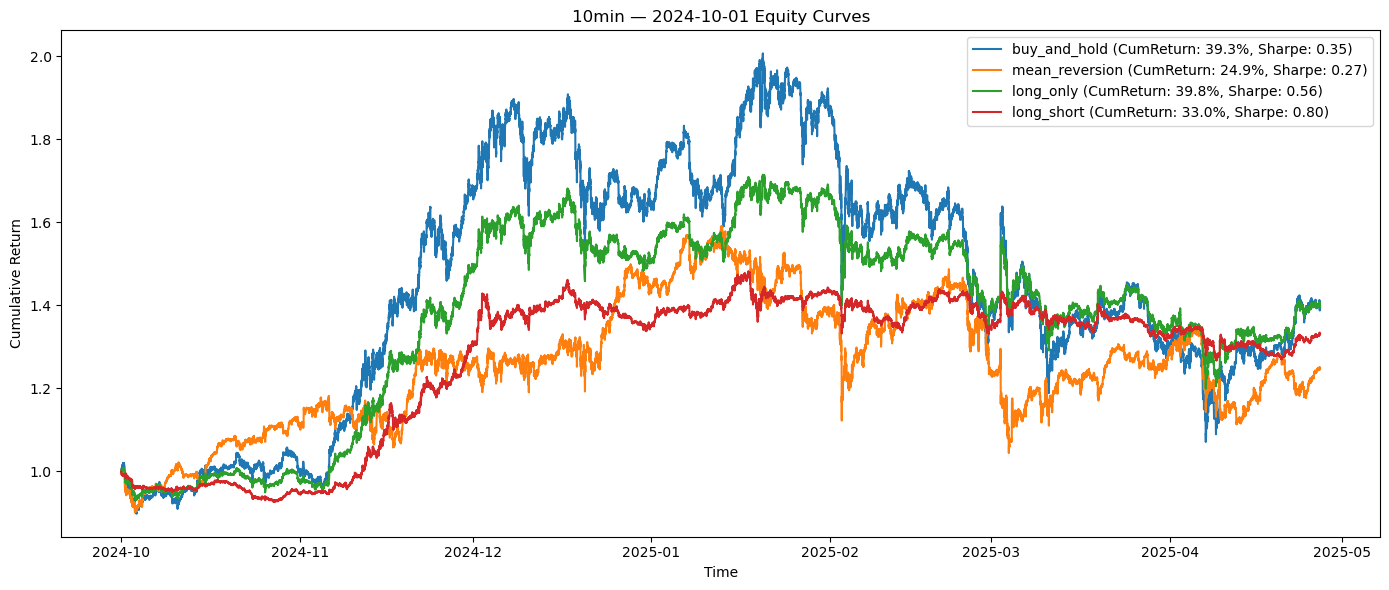

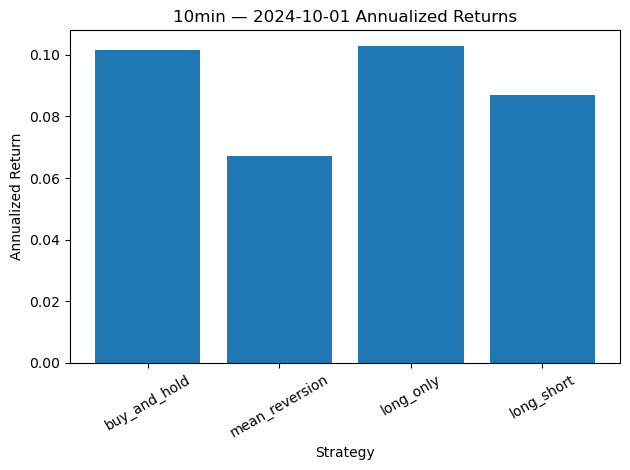


=== Metrics for 2024-10-01, interval=10min ===
                Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold               0.3930             0.1017                 0.2893        0.3516         0.4628           -0.4664        0.2181           0.0079
mean_reversion             0.2490             0.0671                 0.2462        0.2728         0.3363           -0.3436        0.1954           0.0070
long_only                  0.3977             0.1028                 0.1829        0.5623         0.7414           -0.3005        0.3422           0.0104
long_short                 0.3303             0.0870                 0.1081        0.8049         1.1098           -0.1452        0.5989           0.0133


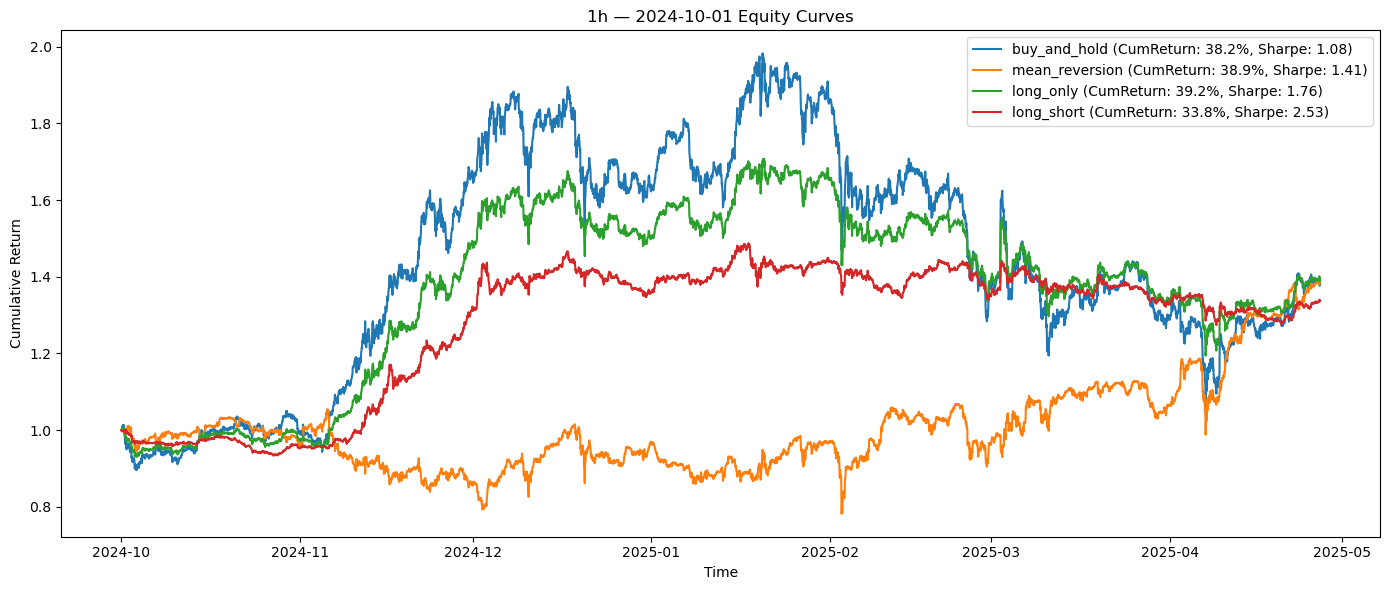

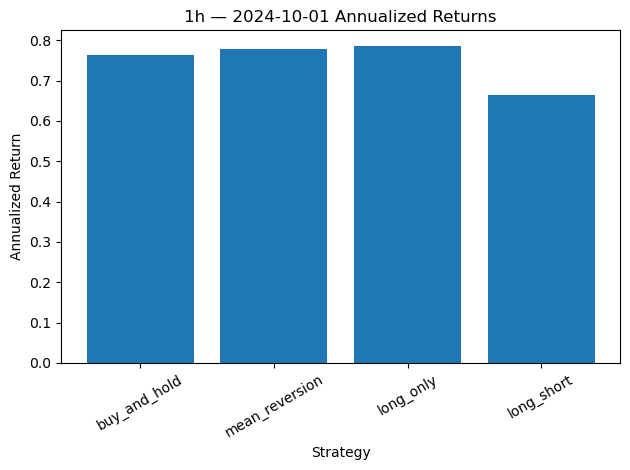


=== Metrics for 2024-10-01, interval=1h ===
                Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold               0.3822             0.7640                 0.7044        1.0846         1.3566           -0.4640        1.6466           0.0193
mean_reversion             0.3886             0.7784                 0.5516        1.4111         1.7250           -0.2584        3.0123           0.0227
long_only                  0.3919             0.7856                 0.4458        1.7623         2.2236           -0.3006        2.6134           0.0256
long_short                 0.3375             0.6652                 0.2634        2.5252         3.4813           -0.1431        4.6473           0.0328


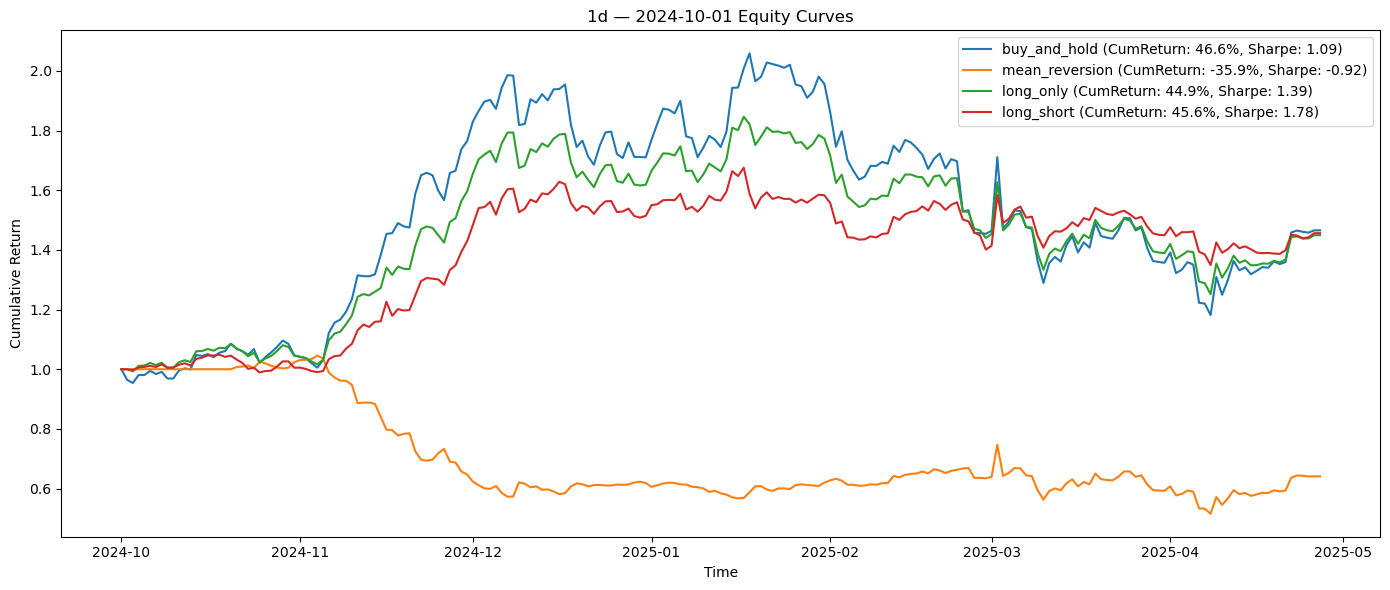

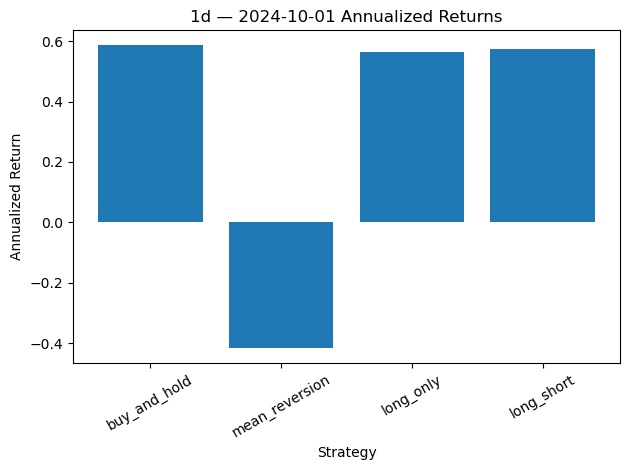


=== Metrics for 2024-10-01, interval=1d ===
                Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold               0.4657             0.5856                 0.5396        1.0853         1.4784           -0.4262        1.3742           0.0956
mean_reversion            -0.3591            -0.4152                 0.4503       -0.9220        -1.1394           -0.5070       -0.8189          -0.1111
long_only                  0.4493             0.5643                 0.4066        1.3879         1.9077           -0.3221        1.7518           0.1150
long_short                 0.4562             0.5733                 0.3220        1.7806         2.6259           -0.1946        2.9456           0.1431


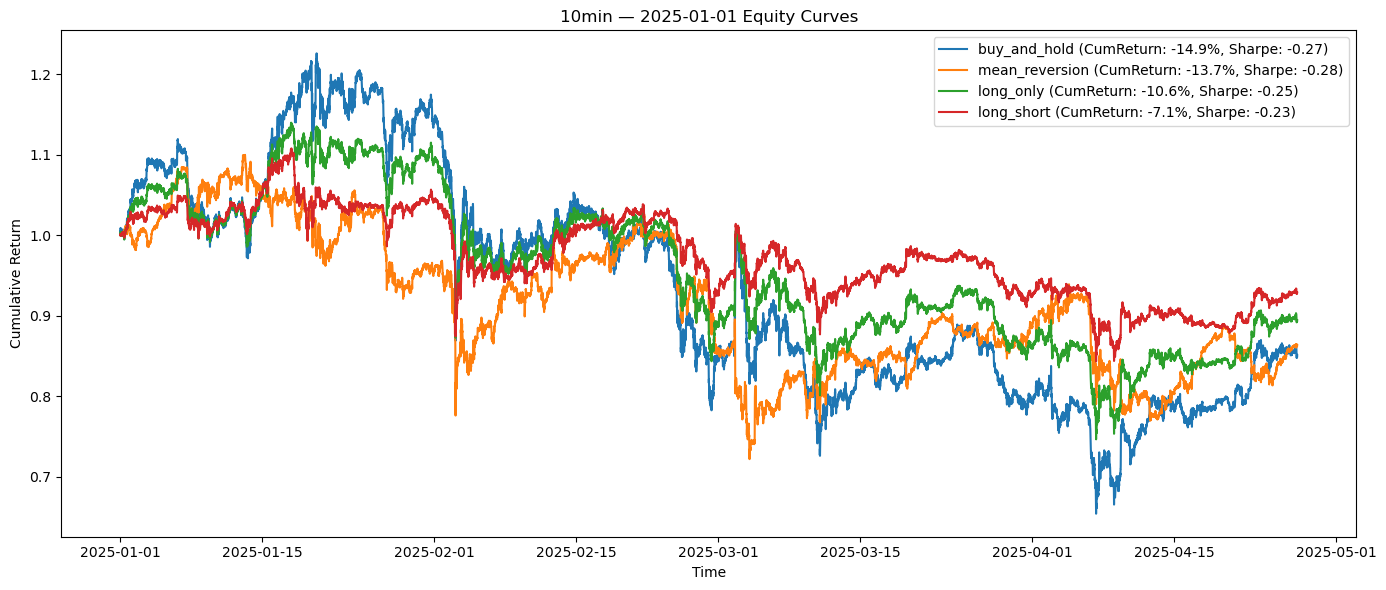

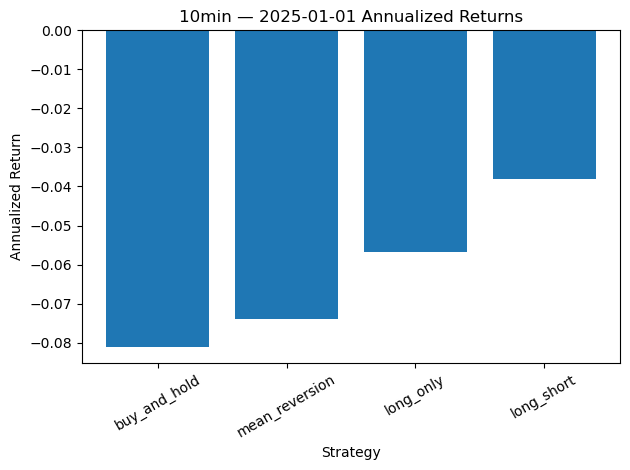


=== Metrics for 2025-01-01, interval=10min ===
                Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold              -0.1492            -0.0811                 0.3038       -0.2670        -0.3539           -0.4664       -0.1740          -0.0021
mean_reversion            -0.1365            -0.0740                 0.2632       -0.2811        -0.3399           -0.3436       -0.2154          -0.0030
long_only                 -0.1057            -0.0568                 0.2289       -0.2483        -0.3229           -0.3450       -0.1647          -0.0024
long_short                -0.0714            -0.0381                 0.1674       -0.2273        -0.2916           -0.2388       -0.1593          -0.0025


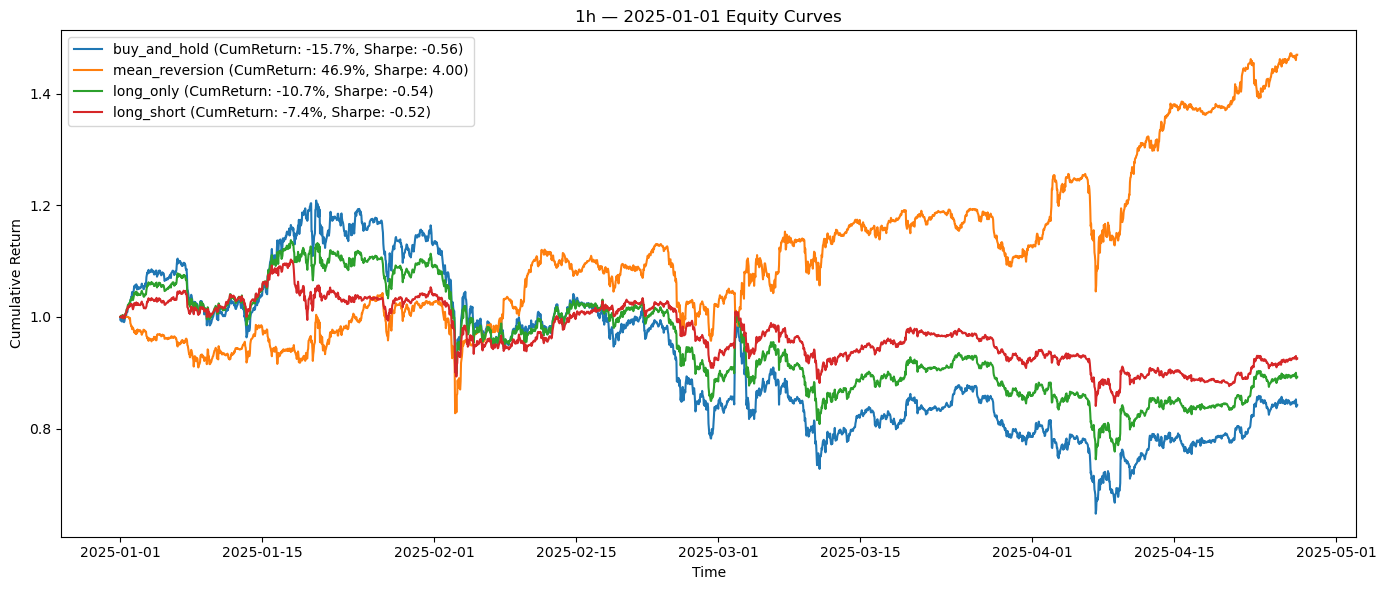

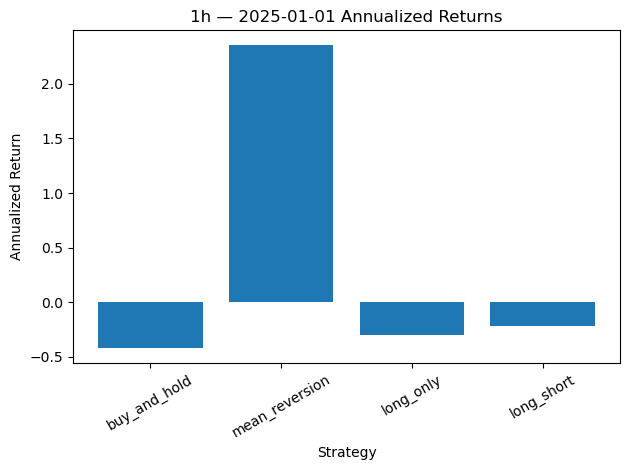


=== Metrics for 2025-01-01, interval=1h ===
                Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold              -0.1575            -0.4163                 0.7450       -0.5588        -0.7033           -0.4640       -0.8973          -0.0059
mean_reversion             0.4694             2.3512                 0.5875        4.0019         4.8778           -0.2064       11.3931           0.0407
long_only                 -0.1072            -0.2998                 0.5601       -0.5353        -0.6563           -0.3449       -0.8693          -0.0061
long_short                -0.0741            -0.2150                 0.4097       -0.5248        -0.6283           -0.2377       -0.9046          -0.0066


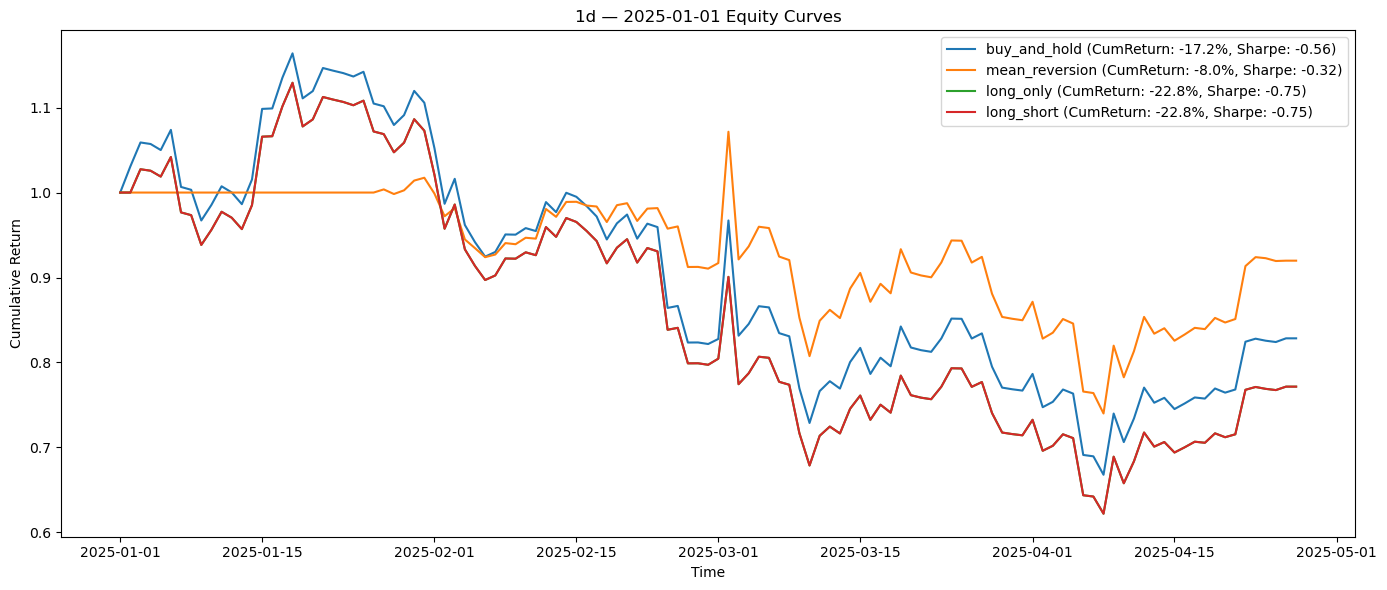

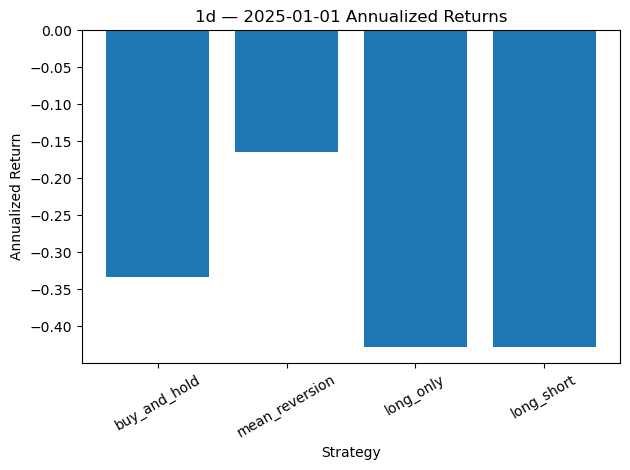


=== Metrics for 2025-01-01, interval=1d ===
                Cumulative Return  Annualized Return  Annualized Volatility  Sharpe Ratio  Sortino Ratio  Maximum Drawdown  Calmar Ratio  Kelly Criterion
buy_and_hold              -0.1716            -0.3333                 0.5980       -0.5573        -0.7508           -0.4262       -0.7821          -0.0347
mean_reversion            -0.0802            -0.1647                 0.5169       -0.3187        -0.3766           -0.3095       -0.5323          -0.0108
long_only                 -0.2284            -0.4280                 0.5698       -0.7511        -0.9641           -0.4492       -0.9528          -0.0631
long_short                -0.2284            -0.4280                 0.5698       -0.7511        -0.9641           -0.4492       -0.9528          -0.0631


In [8]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Assume calculate_performance_metrics and calculate_portfolio_return
# are already defined and available in this notebook.
# -----------------------------------------------------------------------------
warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# Global configuration
# -----------------------------------------------------------------------------
DATA_ROOT   = "data/resampled-v2"
PRED_ROOT   = "results/ARIMA"     # your per-coin ARIMA signal files live here
OUTPUT_DIR  = "results/Backtest"

SPLITS = [
    ("2024-06-01 (80/20)", "ratio"),
    ("2024-10-01",         "2024-10-01"),
    ("2025-01-01",         "2025-01-01"),
]

INTERVALS  = ["10min", "1h", "1d"] # "1min" is not practical
STRATEGIES = ["buy_and_hold", "mean_reversion", "long_only", "long_short"]

# Ensure the output directory exists
os.makedirs(OUTPUT_DIR, exist_ok=True)

for split_label, dirname in SPLITS:
    for iv in INTERVALS:
        # Load test data for this split and interval
        test_fp = os.path.join(DATA_ROOT, dirname, f"test_{iv}.parquet")
        df_test = pd.read_parquet(test_fp)  # requires pyarrow or fastparquet
        df_test["timestamp"] = pd.to_datetime(df_test["timestamp"])
        coins = df_test["coin_id"].unique()

        # Prepare per-coin price DataFrames
        all_data = {
            c: df_test[df_test["coin_id"] == c]
                   .set_index("timestamp")[["open", "high", "low", "close"]]
            for c in coins
        }

        # Load ARIMA model predictions for each coin
        all_preds = {}
        for c in coins:
            pred_fp = os.path.join(PRED_ROOT, dirname, iv, f"{c}.parquet")
            if os.path.exists(pred_fp):
                pdf = pd.read_parquet(pred_fp)
                all_preds[c] = pdf["signal"]

        # Assign equal weights across coins
        weights = {c: 1.0 / len(all_data) for c in all_data}

        # Compute returns and metrics for each strategy
        strat_returns = {}
        metrics       = {}
        for strat in STRATEGIES:
            returns            = calculate_portfolio_return(strat, weights, all_data, all_preds)
            strat_returns[strat] = returns
            metrics[strat]       = calculate_performance_metrics(returns, freq=iv)

        # ---------------------------------------------------------------------
        # Plot cumulative equity curves for all strategies
        # ---------------------------------------------------------------------
        plt.figure(figsize=(14, 6))
        for strat, returns in strat_returns.items():
            equity_curve = (1 + returns).cumprod()
            m = metrics[strat]
            label = (f"{strat} (CumReturn: {m['Cumulative Return']*100:.1f}%, "
                     f"Sharpe: {m['Sharpe Ratio']:.2f})")
            plt.plot(equity_curve.index, equity_curve.values, label=label)

        plt.title(f"{iv} — {split_label} Equity Curves")
        plt.xlabel("Time")
        plt.ylabel("Cumulative Return")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # ---------------------------------------------------------------------
        # Plot annualized returns comparison
        # ---------------------------------------------------------------------
        plt.figure()
        ann_vals = [metrics[s]["Annualized Return"] for s in STRATEGIES]
        plt.bar(STRATEGIES, ann_vals)
        plt.title(f"{iv} — {split_label} Annualized Returns")
        plt.xlabel("Strategy")
        plt.ylabel("Annualized Return")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

        # ---------------------------------------------------------------------
        # Print full KPI table for this split & interval
        # ---------------------------------------------------------------------
        df_kpis = (
            pd.DataFrame(metrics)
              .T[[
                  "Cumulative Return",
                  "Annualized Return",
                  "Annualized Volatility",
                  "Sharpe Ratio",
                  "Sortino Ratio",
                  "Maximum Drawdown",
                  "Calmar Ratio",
                  "Kelly Criterion"
              ]]
        )

        print(f"\n=== Metrics for {split_label}, interval={iv} ===")
        print(df_kpis.to_string(float_format="%.4f"))